In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import plotnine as p9

np.random.seed(42)

sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data/extra-L02").resolve()
assert data_dir.exists()

In [3]:
list(f"{pth.stem}{pth.suffix}" for pth in data_dir.glob("*"))

['tourism.xlsx', 'tute1.csv']

In [4]:
df = (
    pd.read_excel(data_dir / "tourism.xlsx", sheet_name="Sheet1")
    .astype(dict(map(lambda c: (c, "category"), ["Region", "State", "Purpose"])))
    .assign(Quarter=lambda df: pd.to_datetime(df["Quarter"]))
    .set_index(
        ["Quarter", "Region", "State", "Purpose"]
    )
)
df

,,,,Trips
Quarter,Region,State,Purpose,
1998-01-01,Adelaide,South Australia,Business,135.077690
1998-04-01,Adelaide,South Australia,Business,109.987316
1998-07-01,Adelaide,South Australia,Business,166.034687
1998-10-01,Adelaide,South Australia,Business,127.160464
1999-01-01,Adelaide,South Australia,Business,137.448533
...,...,...,...,...
2016-10-01,Yorke Peninsula,South Australia,Visiting,33.672151
2017-01-01,Yorke Peninsula,South Australia,Visiting,46.223014
2017-04-01,Yorke Peninsula,South Australia,Visiting,50.582837


In [5]:
# Find what combination of Region and Purpose had the maximum number of overnight trips on average.
df.groupby(["Region", "Purpose"]).mean().idxmax()

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_12594/2436044702.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Trips    (Sydney, Visiting)
dtype: object

In [6]:
# Create a new tsibble which combines the Purposes and Regions, and just has total trips by State.
df_qs = (
    df.groupby(["Quarter", "State"])
    .sum()
    .reset_index()
    .set_index(["Quarter", "State"])
)
df_qs

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_12594/3395985274.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Trips
Quarter    State                          
1998-01-01 ACT                  551.001921
           New South Wales     8039.794795
           Northern Territory   181.448823
           Queensland          4041.370159
           South Australia     1735.438418
...                                    ...
2017-10-01 Queensland          5813.903667
           South Australia     1869.106985
           Tasmania             800.508499
           Victoria            6865.398851
           Western Australia   2635.754296

[640 rows x 1 columns]

In [7]:
sampled_combination = (
    df
    .reset_index()
    [['Region', 'State', 'Purpose']]
    .drop_duplicates()
    .sample(n=1)
    .iloc[0]
)
sampled_combination

Region             MacDonnell
State      Northern Territory
Purpose              Business
Name: 14400, dtype: object

In [8]:
df_r = (
    df
    .reset_index()
    .query(
        f"Region == '{sampled_combination['Region']}'"
        f"& Purpose == '{sampled_combination['Purpose']}'"
        f"& State == '{sampled_combination['State']}'"
    )
)

print(df_r[["Region", "Purpose", "State"]].value_counts())

df_r = df_r.drop(columns=["Region", "Purpose", "State"]).set_index("Quarter")
df_r

Region      Purpose   State             
MacDonnell  Business  Northern Territory    80
Name: count, dtype: int64


,Trips
Quarter,
1998-01-01,8.616410
1998-04-01,3.337375
1998-07-01,3.825849
1998-10-01,4.543881
1999-01-01,2.972091
...,...
2016-10-01,4.548222
2017-01-01,8.813324
2017-04-01,16.762800


<Axes: xlabel='Quarter', ylabel='Trips'>

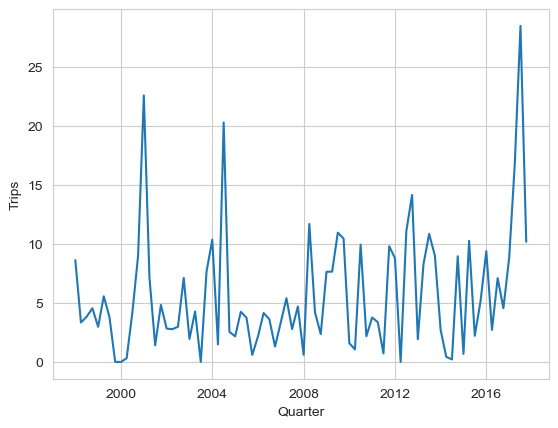

In [9]:
sns.lineplot(data=df_r, x="Quarter", y="Trips")

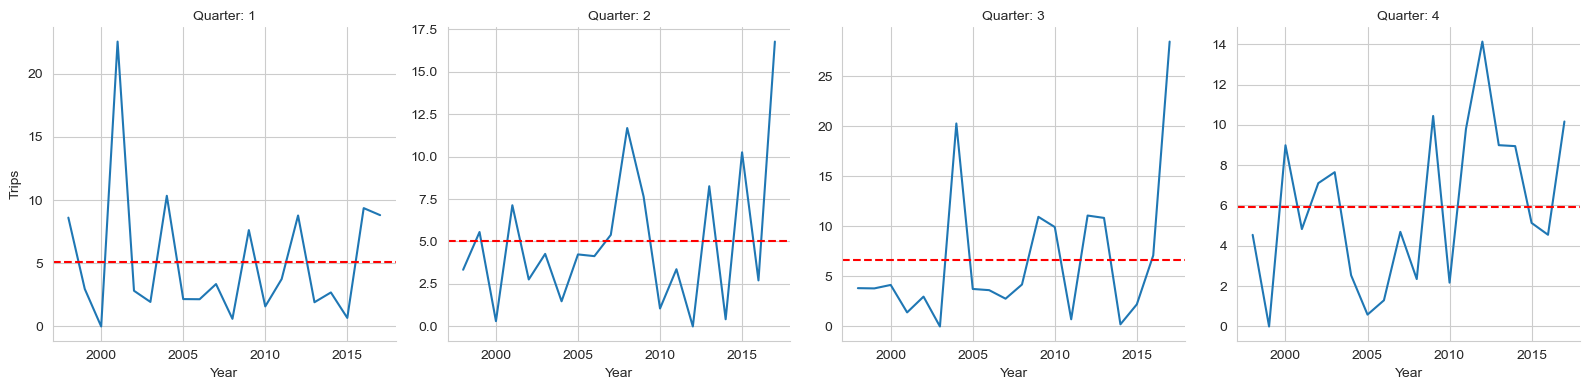

In [11]:
from typing import Literal, Optional


def season_plot(
    df: pd.DataFrame,
    period: Literal["quarter", "month", "week", "day", "hour"],
    value_column: str,
    palette: Optional[str] = 'viridis',
    add_mean_line: bool = False,
) -> sns.FacetGrid:
    """
    Creates a seasonal plot using Seaborn based on the specified period using sns.FacetGrid.

    Args:
        df : pd.DataFrame
            The DataFrame containing the time series data, with the time column as the index.
        period : {'quarter', 'month', 'week', 'day', 'hour'}
            The period over which to plot seasonality.
        value_column : str
            The column name containing the values to be plotted (e.g., temperature, sales, etc.).
        palette : str, optional
            The color palette to use for the lines. Default is 'viridis'.
        add_mean_line : bool, optional
            Whether to add a line representing the mean of the values for each season. Default is False.

    Returns:
        sns.FacetGrid
            A Seaborn FacetGrid object containing the plot.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("The DataFrame must have a DatetimeIndex as its index.")

    # Extract components based on the period
    match period:
        case 'month':
            df['Season'] = df.index.month
            df['Year'] = df.index.year
            x_label = 'Month'
        case 'week':
            df['Season'] = df.index.isocalendar().week
            df['Year'] = df.index.year
            x_label = 'Week'
        case 'quarter':
            df['Season'] = df.index.quarter
            df['Year'] = df.index.year
            x_label = 'Quarter'
        case 'day':
            df['Season'] = df.index.day
            df['Year'] = df.index.year
            x_label = 'Day'
        case 'hour':
            df['Season'] = df.index.hour
            df['Year'] = df.index.year
            x_label = 'Hour'
        case _:
            raise ValueError("Unsupported period. Choose from 'quarter', 'month', 'week', 'day', or 'hour'.")

    # Create the FacetGrid for the seasonal plot
    g = sns.FacetGrid(df, col='Season', col_wrap=4, palette=palette, height=4, sharey=False)
    g.map_dataframe(sns.lineplot, 'Year', value_column)

    # Optionally add a mean line per season
    if add_mean_line:
        mean_values = df.groupby('Season')[value_column].mean().reset_index()
        for ax, season in zip(g.axes.flat, mean_values['Season']):
            ax.axhline(mean_values.loc[mean_values['Season'] == season, value_column].values[0],
                       color='red', linestyle='--', linewidth=1.5)

    # Set common labels and return the grid
    g.set_titles(col_template=f"{x_label}: {{col_name}}")
    g.set_axis_labels('Year', value_column)

    return g

season_plot(df_r, "quarter", "Trips", add_mean_line=True)

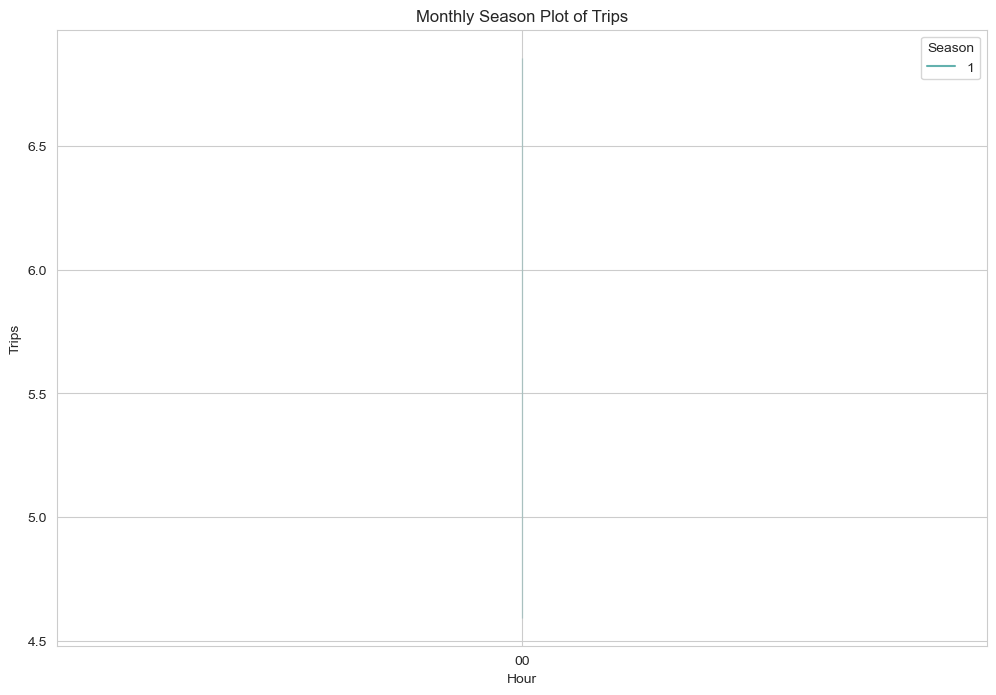

In [30]:
from re import A
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Literal, Optional

def season_plot(
    df: pd.DataFrame,
    period: Literal["quarter", "month", "week", "day"],
    value_column: str,
    hue: Optional[str] = None,
    palette: Optional[str] = 'viridis',
    add_mean_line: bool = False,
) -> plt.Figure:
    """
    Creates a seasonal plot by overlaying all instances of the specified period.

    Args:
        df : pd.DataFrame
            The DataFrame containing the time series data, with the time column as the index.
        period : {'quarter', 'month', 'week', 'day'}
            The period over which to plot seasonality.
        value_column : str
            The column name containing the values to be plotted (e.g., temperature, sales, etc.).
        palette : str, optional
            The color palette to use for the lines. Default is 'viridis'.
        add_mean_line : bool, optional
            Whether to add a line representing the mean of the values for each season. Default is False.

    Returns:
        plt.Figure
            A matplotlib figure containing the plot.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("The DataFrame must have a DatetimeIndex as its index.")

    match period:
        case 'quarter':
            df['Season'] = df.index.quarter
            x_label = 'Quarter'
            x_tick_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        case 'month':
            df['Season'] = df.index.month
            x_label = 'Month'
            x_tick_labels = df.index.strftime('%b').unique()
        case 'week':
            df['Season'] = df.index.isocalendar().week
            x_label = 'Week'
            x_tick_labels = df.index.strftime('%U').unique()
        case 'day':
            df['Season'] = df.index.day
            x_label = 'Hour'
            x_tick_labels = df.index.strftime('%H').unique()
        case _:
            raise ValueError("Unsupported period. Choose from 'quarter', 'month', 'week', or 'day'.")

    # Create the plot using sns.lineplot
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.lineplot(data=df, x='Season', y=value_column, hue=hue or 'Season', palette=palette, ax=ax, alpha=0.7)

    # Add mean line if specified
    if add_mean_line:
        mean_values = df.groupby('Season')[value_column].mean().reset_index()
        ax.plot(mean_values['Season'], mean_values[value_column], color='red', linestyle='--', linewidth=1.5)

    # Set labels and ticks
    ax.set_xlabel(x_label)
    ax.set_ylabel(value_column)
    if x_tick_labels is not None:
        ax.set_xticks(range(1, len(x_tick_labels) + 1))
        ax.set_xticklabels(x_tick_labels)

    return fig


fig = season_plot(df_r, period='day', value_column='Trips', add_mean_line=False)
plt.title('Monthly Season Plot of Trips')
plt.show()

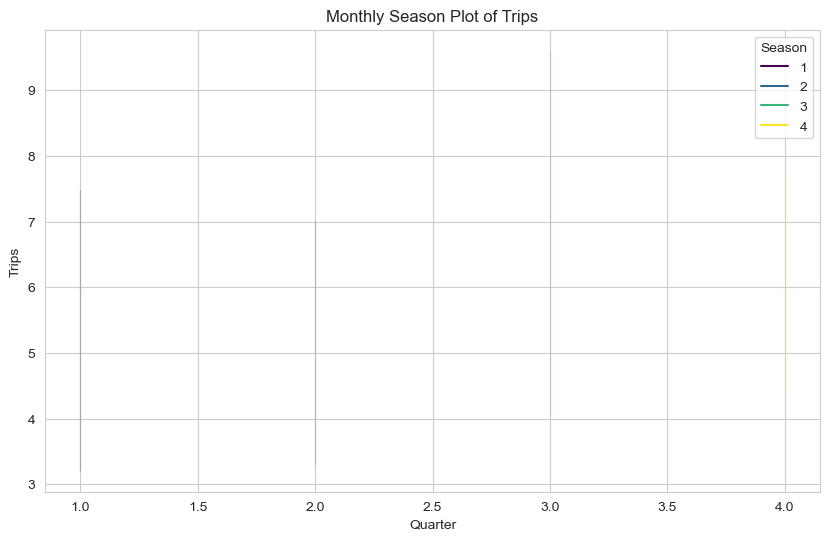

In [15]:
df

,,,,Trips
Quarter,Region,State,Purpose,
1998-01-01,Adelaide,South Australia,Business,135.077690
1998-04-01,Adelaide,South Australia,Business,109.987316
1998-07-01,Adelaide,South Australia,Business,166.034687
1998-10-01,Adelaide,South Australia,Business,127.160464
1999-01-01,Adelaide,South Australia,Business,137.448533
...,...,...,...,...
2016-10-01,Yorke Peninsula,South Australia,Visiting,33.672151
2017-01-01,Yorke Peninsula,South Australia,Visiting,46.223014
2017-04-01,Yorke Peninsula,South Australia,Visiting,50.582837


In [17]:
df.index.names

FrozenList(['Quarter', 'Region', 'State', 'Purpose'])